In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("lahore_house_feature_engineered.csv")

In [3]:
df.columns

Index(['property_id', 'society', 'bedrooms', 'baths', 'built_year',
       'nearby_locations_and_other_facilities', 'rooms', 'link', 'floors',
       'furnished', 'other_business_and_communication_facilities',
       'other_community_facilities', 'lawn_or_garden',
       'other_healthcare_and_recreation_facilities', 'price', 'area',
       'area_sqft', 'servant_quarters', 'kitchens', 'store_rooms',
       'total_rooms', 'price_per_sqft', 'drawing_room', 'dining_room',
       'lounge_or_sitting_room', 'laundry_room', 'study_room', 'prayer_room',
       'powder_room', 'gym', 'steam_room', 'servant_quarters_flag',
       'store_rooms_flag', 'kitchens_flag', 'other_rooms', 'luxury_score',
       'furnishing_score'],
      dtype='object')

In [4]:
df.describe()

,property_id,bedrooms,baths,built_year,price,area,area_sqft,servant_quarters,kitchens,store_rooms,...,prayer_room,powder_room,gym,steam_room,servant_quarters_flag,store_rooms_flag,kitchens_flag,other_rooms,luxury_score,furnishing_score
count,21219.0,21126.000000,21117.000000,15450.000000,21219.000000,21219.000000,21219.000000,13058.000000,17714.000000,13702.000000,...,21219.000000,21219.000000,21219.000000,21219.000000,21219.000000,21219.000000,21219.00000,21219.000000,21219.000000,21219.000000
mean,1.0,4.504639,5.128901,2022.820518,6.359069,12.928291,3519.740067,1.469750,1.970701,1.459495,...,0.687874,0.757387,0.555021,0.610962,0.099345,0.117065,0.04086,0.616664,48.272727,17.456713
std,0.0,1.280145,1.278902,5.355214,8.722298,13.212121,3597.013091,7.183151,1.849558,19.055543,...,0.463372,0.428673,0.496975,0.487544,0.299132,0.321505,0.19797,0.486210,21.427440,8.754970
min,1.0,1.000000,1.000000,1960.000000,0.000550,0.500000,136.125500,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,1.0,3.000000,4.000000,2023.000000,2.200000,5.000000,1361.255000,1.000000,2.000000,1.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,35.000000,13.000000
50%,1.0,5.000000,5.000000,2025.000000,3.750000,10.000000,2722.510000,1.000000,2.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.00000,1.000000,58.000000,24.000000
75%,1.0,5.000000,6.000000,2025.000000,7.500000,20.000000,5445.020000,2.000000,2.000000,2.000000,...,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.00000,1.000000,66.000000,25.000000
max,1.0,34.000000,50.000000,2029.000000,240.000000,786.000000,213989.286000,786.000000,211.000000,2222.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,66.000000,25.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21219 entries, 0 to 21218
Data columns (total 37 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   property_id                                  21219 non-null  int64  
 1   society                                      21219 non-null  object 
 2   bedrooms                                     21126 non-null  float64
 3   baths                                        21117 non-null  float64
 4   built_year                                   15450 non-null  float64
 5   nearby_locations_and_other_facilities        19233 non-null  object 
 6   rooms                                        21219 non-null  object 
 7   link                                         21219 non-null  object 
 8   floors                                       15946 non-null  object 
 9   furnished                                    11690 non-null  object 
 10

In [6]:
df.duplicated().sum()

np.int64(0)

In [11]:
df=df.drop(columns='property_id')

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
pd.set_option("display.max_columns", None)
df.head()


,society,bedrooms,baths,built_year,nearby_locations_and_other_facilities,rooms,link,floors,furnished,other_business_and_communication_facilities,other_community_facilities,lawn_or_garden,other_healthcare_and_recreation_facilities,price,area,area_sqft,servant_quarters,kitchens,store_rooms,total_rooms,price_per_sqft,drawing_room,dining_room,lounge_or_sitting_room,laundry_room,study_room,prayer_room,powder_room,gym,steam_room,servant_quarters_flag,store_rooms_flag,kitchens_flag,other_rooms,luxury_score,furnishing_score
0,DHA Defence,6.0,6.0,2025.0,"Nearby Schools, Nearby Hospitals, Nearby Shopp...","{'Bedrooms': '6', 'Bathrooms': '7', 'Servant Q...",https://www.zameen.com/Property/dha_defence_dh...,2,True,True,True,True,True,19.75,40.0,10890.04,2.0,2.0,2.0,4.0,18152.573529,1,1,1,1,1,1,1,1,1,0,0,0,1,66,25
1,DHA Defence,6.0,7.0,2026.0,"Nearby Schools, Nearby Hospitals, Nearby Shopp...","{'Bedrooms': '6', 'Bathrooms': '7', 'Servant Q...",https://www.zameen.com/Property/dha_defence_dh...,2,True,True,True,True,True,11.50,20.0,5445.02,2.0,3.0,2.0,5.0,21139.705882,1,1,1,1,1,1,1,1,1,0,0,0,1,66,25
2,DHA Defence,6.0,7.0,2025.0,"Nearby Schools, Nearby Hospitals, Nearby Shopp...","{'Bedrooms': '6', 'Bathrooms': '7', 'Servant Q...",https://www.zameen.com/Property/dha_defence_dh...,2,True,True,True,True,True,28.50,40.0,10890.04,2.0,3.0,1.0,4.0,26194.852941,1,1,1,1,1,1,1,1,1,0,0,0,0,66,25
3,DHA Defence,5.0,6.0,2026.0,"Nearby Schools, Nearby Hospitals, Nearby Shopp...","{'Bedrooms': '5', 'Bathrooms': '5', 'Servant Q...",https://www.zameen.com/Property/dha_defence_dh...,2,True,True,True,True,True,9.25,20.0,5445.02,2.0,3.0,1.0,4.0,17003.676471,1,1,1,1,1,1,1,1,1,0,0,0,1,66,25
4,DHA Defence,5.0,6.0,2026.0,"Nearby Schools, Nearby Hospitals, Nearby Shopp...","{'Bedrooms': '2', 'Bathrooms': '2', 'Servant Q...",https://www.zameen.com/Property/dha_phase_7_dh...,1,True,True,True,True,True,7.15,20.0,5445.02,2.0,1.0,NaN,NaN,13143.382353,1,1,1,1,1,1,1,1,1,0,1,0,1,66,25


In [14]:
df['society'].value_counts().shape

(80,)

In [15]:
dict(df['society'].value_counts())

{'DHA Defence': np.int64(6748),
 'Bahria Town': np.int64(1411),
 'Park View City': np.int64(1261),
 'Raiwind Road': np.int64(1012),
 'Johar Town': np.int64(575),
 'Central Park Housing Scheme': np.int64(567),
 'GT Road': np.int64(532),
 'Bahria Orchard': np.int64(497),
 'DHA 11 Rahbar': np.int64(490),
 'Valencia Housing Society': np.int64(428),
 'Wapda Town': np.int64(364),
 'Paragon City': np.int64(349),
 'Allama Iqbal Town': np.int64(339),
 'LDA Avenue': np.int64(333),
 'Askari': np.int64(313),
 'Jubilee Town': np.int64(250),
 'Cantt': np.int64(245),
 'Al Rehman Garden': np.int64(244),
 'Model Town': np.int64(232),
 'Marghzar Officers Colony': np.int64(228),
 'Gulberg': np.int64(216),
 'Formanites Housing Scheme': np.int64(215),
 'Defence Road': np.int64(181),
 'Sabzazar Scheme': np.int64(170),
 'Nasheman-e-Iqbal': np.int64(166),
 'Main Canal Bank Road': np.int64(147),
 'Township': np.int64(145),
 'Eden': np.int64(141),
 'Ferozepur Road': np.int64(136),
 'College Road': np.int64(135)

In [16]:
society_counts = df["society"].value_counts()

frequency_bins = {
    "Very High (>100)": (society_counts > 100).sum(),
    "High (50-100)": ((society_counts >= 50) & (society_counts <= 100)).sum(),
    "Average (10-49)": ((society_counts >= 10) & (society_counts < 50)).sum(),
    "Low (2-9)": ((society_counts > 1) & (society_counts < 10)).sum(),
    "Very Low (1)": (society_counts == 1).sum()
}

frequency_bins


{'Very High (>100)': np.int64(39),
 'High (50-100)': np.int64(19),
 'Average (10-49)': np.int64(22),
 'Low (2-9)': np.int64(0),
 'Very Low (1)': np.int64(0)}

<Axes: xlabel='society'>

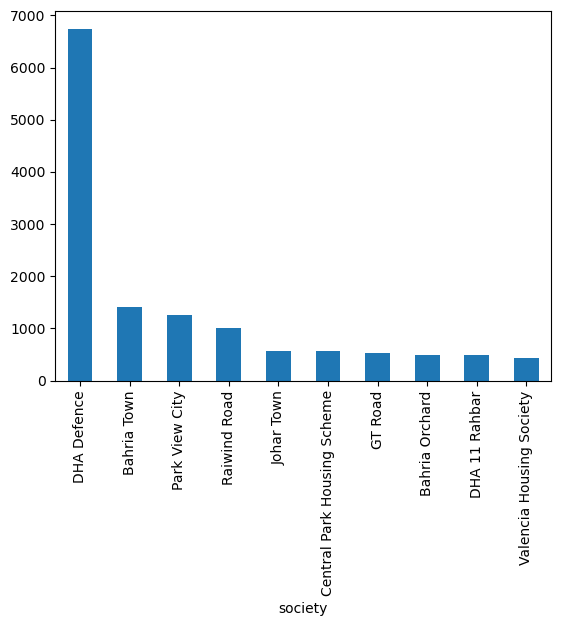

In [17]:
df["society"].value_counts().head(10).plot(kind='bar')

In [18]:
df['society'].isnull().sum()

np.int64(0)

## Price

In [19]:
df['price'].isnull().sum()

np.int64(0)

In [20]:
df['price'].value_counts()

price
2.1000    392
3.5000    343
2.2500    326
2.3000    326
6.5000    314
         ... 
0.9550      1
0.9950      1
0.5475      1
0.7400      1
0.9995      1
Name: count, Length: 1026, dtype: int64

In [21]:
df['price'].describe()

count    21219.000000
mean         6.359069
std          8.722298
min          0.000550
25%          2.200000
50%          3.750000
75%          7.500000
max        240.000000
Name: price, dtype: float64

<Axes: xlabel='price', ylabel='Count'>

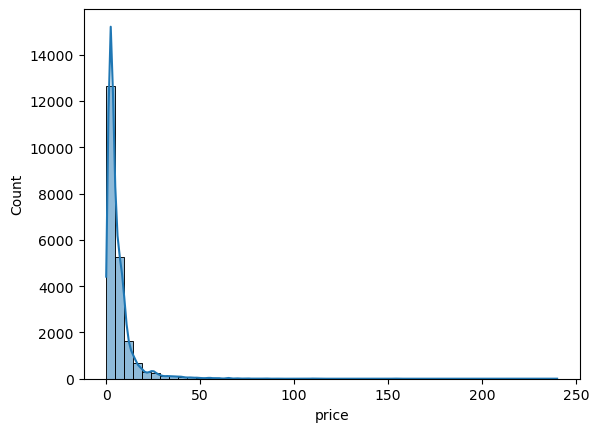

In [22]:
sns.histplot(df["price"], kde=True, bins=50)

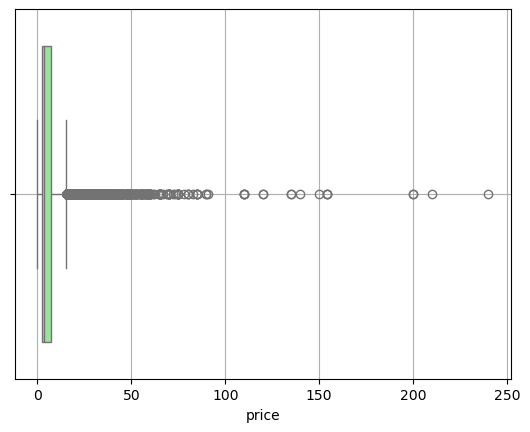

In [23]:
sns.boxplot(x=df["price"], color="lightgreen")
plt.grid()


In [24]:
# Skewness and Kurtosis
skewness = df["price"].skew() # how much your data skwed 
kurtosis = df["price"].kurt() # how much haviness in tail
print(skewness, kurtosis)


7.166398569520752 102.7258278510048


In [25]:
# Quantile Analysis
quantiles = df["price"].quantile([0.01, 0.05, 0.95, 0.99])
quantiles


0.01     0.70
0.05     1.22
0.95    19.00
0.99    42.00
Name: price, dtype: float64

In [26]:
# Identify potential outliers using IQR method
Q1 = df["price"].describe()["25%"]
Q3 = df["price"].describe()["75%"]
IQR = Q3 - Q1
IQR


np.float64(5.3)

In [27]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(lower_bound, upper_bound)


-5.749999999999999 15.45
